# Modeling Intro: First RGB Barycentric Triangle

## Introduction

This notebook starts with code that already works and produces a meaningful result. That is often exactly what we need in science: something correct enough to explore an idea. We start with writing code in Jupyter notebooks because it is quick and easy for the programmer.

In CMSE 802, we build from that success by adding a few software engineering habits that are:

- quick to apply
- easy to understand
- high impact for readability and reuse

The goal is to build from a working concept and make code that is [***Safe, Portable, Reproducible, Robust and Literate***](https://colbrydi.github.io/Research_guidelines/Rules_for_Repos.html).

## What To Do

1. Run the code cell below to generate the triangle image.
2. Work with your team to understand what the code is doing.
3. Make one small change.
4. Re-run the code cell.
5. Observe what changed.
6. Discuss why the change helps.

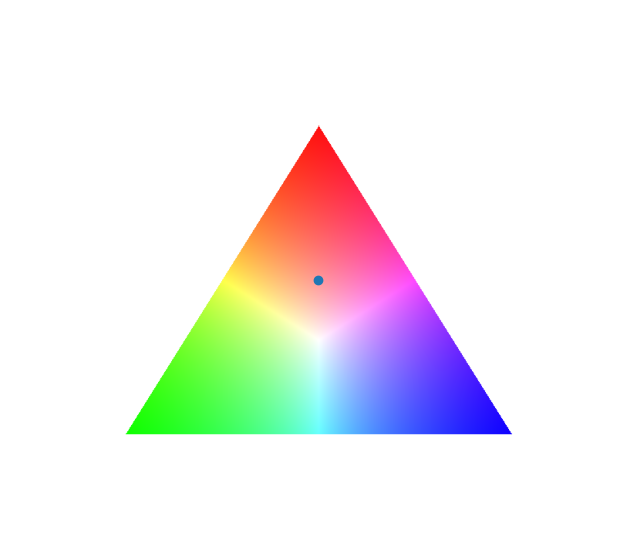

In [6]:
import numpy as np
import matplotlib.pyplot as plt


# Image size
width = 800
height = 700

# Create empty RGB image initialized to white
image = np.ones((height, width, 3), dtype=float)

# Triangle vertices
red_point = np.array([width / 2, 100])          # top
green_point = np.array([100, height - 100])     # bottom left
blue_point = np.array([width - 100, height - 100])  # bottom right


def point_in_triangle(p, a, b, c):
    """
    Return True if point p is inside triangle abc.
    Uses barycentric coordinates.
    """
    v0 = c - a
    v1 = b - a
    v2 = p - a

    dot00 = np.dot(v0, v0)
    dot01 = np.dot(v0, v1)
    dot02 = np.dot(v0, v2)
    dot11 = np.dot(v1, v1)
    dot12 = np.dot(v1, v2)

    denom = dot00 * dot11 - dot01 * dot01

    u = (dot11 * dot02 - dot01 * dot12) / denom
    v = (dot00 * dot12 - dot01 * dot02) / denom

    return (u >= 0) and (v >= 0) and (u + v <= 1)

def plot_triangle(point = " ", width = 800, height = 700, border = 150):

    image = np.ones((height, width, 3), dtype = float)

    red_point = np.array([width / 2, border]) # top
    green_point = np.array([border, height - border]) # bottom left
    blue_point = np.array([width - border, height - border]) # bottom left

    # Maximum possible distance inside triangle
    max_dist = max(
        np.linalg.norm(red_point - green_point),
        np.linalg.norm(red_point - blue_point),
        np.linalg.norm(green_point - blue_point),
    )
    
    # Loop through every pixel
    for y in range(height):
        for x in range(width):
    
            p = np.array([x, y])
    
            if point_in_triangle(
                p,
                red_point,
                green_point,
                blue_point
            ):
    
                d_red = np.linalg.norm(p - red_point)
                d_green = np.linalg.norm(p - green_point)
                d_blue = np.linalg.norm(p - blue_point)
    
                # Convert distances into "closeness"
                r = 1.0 - d_red / max_dist
                g = 1.0 - d_green / max_dist
                b = 1.0 - d_blue / max_dist
    
                color = np.array([r, g, b])
    
                # Normalize so colors remain vivid
                color /= color.max()
    
                image[y, x] = color
    
    # Display result
    plt.figure(figsize=(8, 7))
    plt.imshow(image)
            
    plt.axis("off")

plot_triangle()
plt.scatter(400,350)
plt.savefig("./plot.png")

# Improving the Triangle Generator

The code currently works and produces a useful figure.

In this section, your goal is not to change the overall behavior of the program. Instead, you will make a series of small improvements that make the code easier to understand, modify, reuse, and maintain.

As you work through these exercises, think about how your changes contribute to software that is:

- Safe
- Portable
- Reproducible
- Robust
- Literate

After each change, run the code and verify that it still produces a valid figure.

## Exercise 1: Eliminate Magic Numbers

Find the hard-coded values that define the border around the triangle.

Create a variable named:

```python
border
```

and replace the repeated raw values with the new variable.

Experiment with different values of `border` and observe how the figure changes.

### Team/Class Reflection
- What does the border represent?
- Why is a named variable easier to understand than a raw number?
- How might this change make the code more robust?
- Are there any other magic numbers we should define as variables?
- How could you eliminate magic numbers without a variable?

## Exercise 2: Convert the Script to a Function

The current code executes from top to bottom as a script. Now we want to make it more portable by turning it into a function:

- Refactor the code into a function using `def` that generates the triangle.
- Choose a set of inputs that would be useful to another programmer.
- Provide reasonable default values.

Test your function using several different inputs.

### Team/Class Reflection

- What did you name your function? Is the name useful?
- Which values belong as function inputs?
- Which values should remain internal details?
- How do default arguments make software easier to use?
- How might this help make the code more portable?

## Exercise 3: Add a Project Point

Create a new function that adds a point somewhere inside the triangle. The point should be displayed on top of the generated image. Experiment with different locations and styles.

Imagine this point represents your research project positioned within the RGB framework where RGB is:

- Red = Analytical
- Green = Physical
- Blue = Data-Driven

### Team/Class Reflection

- What did you name your new function? Is the name useful?
- What information should the function require?
- What information could be optional?
- Would another student understand how to use your function?

## Exercise 4: Save the Figure

Modify the code so a user can save the generated figure to a file.

Consider whether saving should always happen, never happen, or be controlled through a function argument.

Adjust your implementation.

### Team/Class Reflection

- Why is saving generated figures useful in research?
- How can saved figures support reproducible workflows?
- What file naming practices might help keep projects organized?

## Exercise 5: Make the Code More Literate

Imagine another student needs to use your code next semester.

Improve the code so it is easier to understand.

Possible ideas include:

- better variable names
- add comments and docstrings
- clearer function names

### Team/Class Reflection

- What change did you make?
- How does it improve readability?
- How does it support literate software?

You are done with this notebook. Move on to the next notebook to learn how to make your code more portable using a Python library.